In [16]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import savemat
from scipy.signal import butter, filtfilt, sosfiltfilt
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import (
    linkage,
    dendrogram,
    optimal_leaf_ordering,
    fcluster,
    leaves_list,
)
from scipy.stats import zscore
from sklearn.metrics import silhouette_score
from matplotlib.colors import ListedColormap
import matplotlib as mpl
from matplotlib.ticker import ScalarFormatter
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
)
from scipy.signal import argrelmax, argrelmin
from scipy.ndimage import gaussian_filter1d
from scipy.signal import hilbert
from scipy import stats as ss
import igraph as ig
import matplotlib.colors as mcolors
from sklearn.preprocessing import MinMaxScaler
from mpl_toolkits.axes_grid1 import make_axes_locatable
from sklearn.neighbors import KernelDensity
import matplotlib.ticker as mticker
from scipy.integrate import cumulative_trapezoid
from time import time
import os
import networkx as nx
import gc
from joblib import Parallel, delayed
import psutil
import copy
from matplotlib.collections import LineCollection


mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["font.size"] = 8
mpl.rcParams["font.style"] = "normal"
mpl.rcParams["font.weight"] = "normal"
mpl.rcParams["font.stretch"] = "normal"
mpl.rcParams["xtick.direction"] = "in"
mpl.rcParams["ytick.direction"] = "in"

In [17]:
# ========================== HELPER FUNCTIONS ==============================
# freqs = np.array([0.5, 1, 2, 4])
# freqIndex = 3
def lowpass_smooth_by_freq(x, dt, fc_hz):
    x = x.astype(float)
    fs = 1.0 / dt
    nyq = fs / 2.0
    fc_hz = np.clip(fc_hz, 1e-6, 0.999 * nyq)
    Wn = fc_hz / nyq
    sos = butter(1, Wn, btype="low", output="sos")
    y = sosfiltfilt(sos, x, padtype="odd")
    y[y < 0] = 0
    return y


# taus = np.array([0.2, 1.0, 2.5, 5.0])
# tauIndex = 3
def lowpass_butter(x, wc):
    # 1st-order Butterworth low-pass; wc in (0,1) normalized
    x = x.astype(float)
    wc = max(min(wc, 0.999), 1e-3)
    b, a = butter(1, wc, btype="low")
    y = filtfilt(b, a, x)
    y[y < 0] = 0
    return y


# gaus = np.array([0.5, 1, 2]) * dtFR
# gauIndex = 1
def lowpass_smooth_by_gaussian(x, sigma_sec, dt, truncate=3.0, mode="reflect"):
    x = np.asarray(x, dtype=float)
    sigma = sigma_sec / dt
    return gaussian_filter1d(x, sigma=sigma, truncate=truncate, mode=mode)


def gaussian_smooth_by_period(
    x, period_sec, dt, truncate=3.0, mode="reflect", definition="3db"
):
    x = np.asarray(x, dtype=float)
    if definition == "3db":
        sigma_sec = 0.13250518 * period_sec
    elif definition == "e1":
        sigma_sec = 0.22507908 * period_sec
    else:
        raise ValueError("definition must be '3db' or 'e1'")
    sigma = sigma_sec / dt

    K = 2 * int(truncate * float(sigma) + 0.5) + 1
    width_sec = (K - 1) * dt
    print(
        f"period_sec = {period_sec:.6f} s, sigma_sec = {sigma_sec:.6f} s, kernel_points = {K}, kernel_width = {width_sec:.6f} s"
    )

    return gaussian_filter1d(x, sigma=sigma, truncate=truncate, mode=mode)


def load_sampling_rate(ksDir: Path, fsOverride=None):

    if fsOverride is not None:
        return float(fsOverride)

    paramsPy = ksDir.joinpath("params.py")
    if not paramsPy.exists():
        raise RuntimeError(
            "params.py not found; cannot determine sampling rate. "
            "Set fsOverride manually."
        )

    txt = paramsPy.read_text()
    m = re.search(r"sample_rate\s*=\s*([\d\.]+)", txt)
    if m:
        return float(m.group(1))
    else:
        raise RuntimeError(
            "Could not parse sample_rate from params.py. " "Set fsOverride manually."
        )


def set_axis_scientific_powerlimits(axe, xaxis=False, yaxis=False):
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((0, 0))
    if xaxis:
        axe.xaxis.set_major_formatter(formatter)
    if yaxis:
        axe.yaxis.set_major_formatter(formatter)


def zscoring(Y, baseline, eps=1e-8):
    """
    Y: (N, T)
    baseline: 1D bool/int index, or slice, selecting baseline time points
    """
    if baseline.shape[0] == Y.shape[1]:
        return zscore(Y, axis=1, ddof=0), None, None
    Y = np.asarray(Y)
    Yb = Y[:, baseline]
    mub = Yb.mean(axis=1, keepdims=True)
    sdb = np.maximum(Yb.std(axis=1, keepdims=True), eps)
    Yz = (Y - mub) / sdb
    return Yz, mub, sdb


def getwin(nBins):
    aggPreAlone = np.arange(0, int(nBins / 9))
    aggDuration = np.arange(int(nBins / 9), int(2 * nBins / 9))
    aggPostAlone = np.arange(int(2 * nBins / 9), int(3 * nBins / 9))
    foodPreAlone = np.arange(int(3 * nBins / 9), int(4 * nBins / 9))
    foodDuration = np.arange(int(4 * nBins / 9), int(5 * nBins / 9))
    foodPostAlone = np.arange(int(5 * nBins / 9), int(6 * nBins / 9))
    fearPreAlone = np.arange(int(6 * nBins / 9), int(7 * nBins / 9))
    fearDuration = np.arange(int(7 * nBins / 9), int(8 * nBins / 9))
    fearPostAlone = np.arange(int(8 * nBins / 9), int(9 * nBins / 9))
    winA = np.concatenate([aggPreAlone, aggDuration, aggPostAlone])
    winF = np.concatenate([foodPreAlone, foodDuration, foodPostAlone])
    winP = np.concatenate([fearPreAlone, fearDuration, fearPostAlone])
    winPre = np.concatenate([aggPreAlone, foodPreAlone, fearPreAlone])
    winDur = np.concatenate([aggDuration, foodDuration, fearDuration])
    winPost = np.concatenate([aggPostAlone, foodPostAlone, fearPostAlone])
    winAll = np.concatenate([winA, winF, winP])
    return (
        aggPreAlone,
        aggDuration,
        aggPostAlone,
        foodPreAlone,
        foodDuration,
        foodPostAlone,
        fearPreAlone,
        fearDuration,
        fearPostAlone,
        winA,
        winF,
        winP,
        winPre,
        winDur,
        winPost,
        winAll,
    )


def smoothing_plot(fr, frSmoothed, dtFR, N=100, plot=True):
    if plot:
        t = np.arange(N) * dtFR
        units_to_plot = [0, 1, 2]
        fig, axes = plt.subplots(
            nrows=len(units_to_plot),
            ncols=1,
            sharex=True,
            figsize=(5, 3),
        )
        for ax, u in zip(axes, units_to_plot):
            ax.plot(t, fr[u, :N], label="raw")
            ax.plot(t, frSmoothed[u, :N], label="smoothed")
            ax.set_ylabel("Hz")
            ax.set_title(f"Unit {u}", fontsize=10)
            ax.grid(True, alpha=0.2)
            ax.legend(loc="upper right", fontsize=8)
        axes[-1].set_xlabel("Time (s)")
        fig.suptitle(f"Raw vs Smoothed (first {N} bins)", y=0.98, fontsize=12)
        fig.tight_layout()
        plt.show()
        plt.close()


def binary_fr(fr, frAdd, goodcluBestChAreaCode, nAreas, areaNamesFull, plot=True):
    if plot:
        frBinary = np.concatenate([fr, frAdd])
        frBinary[frBinary != 0] = 1
        nGood, nBins = frBinary.shape

        fig, (axBrain, axFRBA, axFRBF, axFRBP) = plt.subplots(
            1,
            4,
            figsize=(4.5, 3),
            gridspec_kw={"width_ratios": [0.5, 2, 2, 2]},
        )

        gap = 0.01
        posA = axFRBA.get_position()
        posF = axFRBF.get_position()
        posP = axFRBP.get_position()
        width = posA.width
        axFRBA.set_position([posA.x0, posA.y0, width, posA.height])
        axFRBF.set_position([posA.x0 + width + gap, posF.y0, width, posF.height])
        axFRBP.set_position([posA.x0 + 2 * (width + gap), posP.y0, width, posP.height])

        reOrder = np.argsort(goodcluBestChAreaCode)
        areaCodesOrdered = goodcluBestChAreaCode[reOrder]
        print(areaCodesOrdered[:20])
        print(areaCodesOrdered[-20:])
        brainMat = areaCodesOrdered[:, None]
        areaColorList = plt.get_cmap("Paired").colors[:nAreas]
        cmapArea = ListedColormap(areaColorList)
        imBrain = axBrain.imshow(
            brainMat,
            cmap=cmapArea,
            origin="lower",
            aspect="auto",
            interpolation="none",
            vmin=-0.5,
            vmax=nAreas - 0.5,
        )
        axBrain.set_xticks([])
        uniqueAreas = np.unique(areaCodesOrdered)
        yticks = []
        ylabels = []
        for a in uniqueAreas:
            idx = np.where(areaCodesOrdered == a)[0]
            y_center = idx.mean()
            yticks.append(y_center)
            ylabels.append(areaNamesFull[int(a)])
        axBrain.set_yticks(yticks)
        axBrain.set_yticklabels(ylabels, rotation=0)
        axBrain.tick_params(direction="in")
        axBrain.set_title("Brain" + "\n" + "Areas", fontweight="bold")

        axList = [axFRBA, axFRBF, axFRBP]
        sList = [0, int(nBins / 3), int(2 * nBins / 3)]
        eList = [int(nBins / 3), int(2 * nBins / 3), int(3 * nBins / 3)]
        lastIm = None
        for ax, s, e in zip(axList, sList, eList):
            # z-scored firing rate
            im = ax.imshow(
                frBinary[reOrder, s:e],
                cmap="gray_r",
                origin="lower",
                aspect="auto",
                interpolation="none",
                vmin=0,
                vmax=1,
            )
            lastIm = im
            tick_pos = np.array([nBins / 9, 2 * nBins / 9])
            tick_labels = np.array([5, 10])
            ax.set_xticks(tick_pos)
            ax.set_xticklabels(tick_labels)
            ax.set_yticks([0, int((nGood - 1) / 2), (nGood - 1)])
            ax.set_yticklabels([0 + 1, int((nGood - 1) / 2) + 1, (nGood - 1) + 1])
            # set_axis_scientific_powerlimits(axe=ax, xaxis=True, yaxis=False)
            ax.tick_params(direction="in")
            ax.yaxis.set_label_position("right")
            ax.yaxis.tick_right()
            if ax in [axFRBA, axFRBF]:
                ax.set_ylabel("")
                ax.set_yticklabels([])
                ax.tick_params(axis="y", which="both", left=False, right=False)
            else:
                ax.set_ylabel("GOOD units", fontweight="bold")
            if ax in [axFRBF]:
                ax.set_xlabel("Time (mins)")
            if ax in [axFRBA, axFRBF]:
                ax.xaxis.get_offset_text().set_visible(False)
            if ax == axFRBA:
                ax.set_title("Aggression", fontweight="bold")
            if ax == axFRBF:
                ax.set_title("Food-Intake", fontweight="bold")
            if ax == axFRBP:
                ax.set_title("Predator-Fear", fontweight="bold")
        plt.show()
        plt.close()


def is_power_of_10(x, rtol=1e-8, atol=0.0):
    x = float(x)
    if x <= 0 or not np.isfinite(x):
        return False
    k = np.log10(x)
    return np.isclose(k, np.round(k), rtol=rtol, atol=atol)


def sci_tex(x):
    if x == 0:
        return "0"
    exp = int(np.floor(np.log10(abs(x))))
    mant = x / (10**exp)
    if np.isclose(mant, 1.0):
        return rf"$10^{{{exp}}}$"
    return rf"${mant:g}\times10^{{{exp}}}$"

In [18]:
# ========================== DATA FUNCTIONS ==============================
def data_extraction_fr(
    dtFR,
    phyPathList,
    clusterInfoPathList,
    miceNames,
    brainArea,
    areaNames,
    fsOverride=None,
):
    """
    ANALYZE_KS_AND_PLOT_RAW (GOOD units only, with brain areas)
    - Loads Kilosort/Phy outputs
    - Uses Phy manual curation (cluster_info.tsv) to keep only GOOD units
    - Assigns each unit to a brain area from histology-based probe map
    - Builds spike raster
    """

    frListOrig = []
    goodcluBestchList = []
    goodcluBestChAreaStrList = []
    goodcluBestChAreaCodeList = []
    goodcluToMiceList = []
    totalnUnits = 0
    totalnUnitsGood = 0
    TminSec = None
    TmaxSec = None
    for phyPath, clusterInfoPath, miceId in zip(
        phyPathList, clusterInfoPathList, miceNames
    ):
        # Loads from KS / Phy
        spikeAmplitudes = np.load(phyPath.joinpath("amplitudes.npy"))
        spikeTimes = np.load(phyPath.joinpath("spike_times.npy")).astype(float)
        spikeClusters = np.load(phyPath.joinpath("spike_clusters.npy")).astype(int)

        # Sample rate and units
        fs = load_sampling_rate(phyPath, fsOverride)
        print(f"Using sampling rate fs = {fs:.3f} Hz")
        unitIdx = spikeClusters
        spikeSec = spikeTimes / fs
        nUnits = np.unique(unitIdx).shape[0]
        TminSec = 0 * float(spikeSec.max()) / 3
        TmaxSec = 3 * float(spikeSec.max()) / 3
        totalnUnits += nUnits

        # LOAD PHY MANUAL CURATION
        if not clusterInfoPath.exists():
            raise FileNotFoundError(f"cluster_info.tsv not found in {phyPath}")
        cluInfo = pd.read_csv(clusterInfoPath, sep="\t")
        if "cluster_id" not in cluInfo.columns or "group" not in cluInfo.columns:
            raise RuntimeError(
                "cluster_info.tsv must contain 'cluster_id' and 'group' columns."
            )
        cluId = cluInfo["cluster_id"].to_numpy(dtype=int)
        cluGrp = cluInfo["group"].astype(str).to_numpy()
        goodUnitsIdx = np.where(cluGrp == "good")[0]
        muaUnitsIdx = np.where(cluGrp == "mua")[0]
        noiseUnitsIdx = np.where(cluGrp == "noise")[0]
        totalnUnitsGood += goodUnitsIdx.shape[0]
        print(
            f"Detected [{nUnits} ({totalnUnits})] [{goodUnitsIdx.shape[0]} ({totalnUnitsGood})] units; recording duration {TmaxSec:.1f} s"
        )

        # MAP EACH UNIT TO A BRAIN AREA
        cluBestCh = cluInfo["ch"].to_numpy(dtype=int)
        cluBestChAreaStr = np.zeros_like(cluBestCh, dtype=object)
        cluBestChAreaCode = np.zeros_like(cluBestCh, dtype=int)
        for uid in range(nUnits):
            for aid, name in enumerate(areaNames):
                areaIdxs = brainArea[name]
                cBC = cluBestCh[uid] + 1
                if cBC in areaIdxs:
                    cluBestChAreaStr[uid] = name
                    cluBestChAreaCode[uid] = aid
                    break
        goodcluBestchTemp = cluBestCh[goodUnitsIdx]
        goodcluBestChAreaStrTemp = cluBestChAreaStr[goodUnitsIdx]
        goodcluBestChAreaCodeTemp = cluBestChAreaCode[goodUnitsIdx]
        goodcluBestchList.append(goodcluBestchTemp)
        goodcluBestChAreaStrList.append(goodcluBestChAreaStrTemp)
        goodcluBestChAreaCodeList.append(goodcluBestChAreaCodeTemp)

        # Mouse Id
        goodcluToMiceList.append(np.zeros(goodUnitsIdx.shape[0]) + miceId)

        # FIRING RATES and Z-SCORE
        edges = np.arange(TminSec, TmaxSec + dtFR, dtFR)
        frTempOrig = np.array(
            [
                np.histogram(spikeSec[unitIdx == uid], edges)[0] / dtFR
                for uid in goodUnitsIdx
            ]
        )
        frListOrig.append(frTempOrig)
    nGood = totalnUnitsGood
    nBins = np.arange(TminSec, TmaxSec + dtFR, dtFR).shape[0] - 1
    goodcluBestch = np.concatenate(goodcluBestchList, axis=0)
    goodcluBestChAreaStr = np.concatenate(goodcluBestChAreaStrList, axis=0)
    goodcluBestChAreaCode = np.concatenate(goodcluBestChAreaCodeList, axis=0)
    goodcluToMice = np.concatenate(goodcluToMiceList, axis=0)

    fr = np.concatenate(frListOrig, axis=0)
    return (
        nGood,
        nBins,
        goodcluBestch,
        goodcluBestChAreaStr,
        goodcluBestChAreaCode,
        goodcluToMice,
        fr,
    )


def data_extraction_smooth_zscore(
    fr,
    dtFR,
    smoothperd,
    smoothperdvisual,
):
    """
    Input:
      fr: (nGood, nBins) raw firing rates

    Output (same logic as original):
      frSmoothed: (nGood, nBins)
      frSmoothedVisual: (nGood, nBinsVisual), where nBinsVisual = nBins // each
    """
    fr = np.asarray(fr, float)
    nGood, nBins = fr.shape

    each = int(round(smoothperdvisual / dtFR))
    nBinsVisual = nBins // each
    frSmoothed = np.zeros((nGood, nBins))
    frSmoothedVisual = np.zeros((nGood, nBinsVisual))

    for uidg in range(nGood):
        smooth = gaussian_smooth_by_period(
            x=fr[uidg, :], period_sec=smoothperd, dt=dtFR
        )
        frSmoothed[uidg, :] = smooth
        frSmoothedVisual[uidg, :] = smooth.reshape((-1, each)).mean(axis=1)

    return frSmoothed, frSmoothedVisual

In [19]:
# ========================== CLUSTERING FUNCTIONS ==============================
def _bh_cutoff(p_candidates, m_total, alpha=0.05):
    """
    Exact BH cutoff given:
      - p_candidates: all p-values that are <= alpha (others are > alpha and cannot pass BH anyway)
      - m_total: total number of tests = n*(n-1)/2
    Returns cutoff (float) or None if nothing passes.
    """
    if p_candidates.size == 0:
        return None

    order = np.argsort(p_candidates)
    p_sorted = p_candidates[order]

    # BH threshold uses m_total (ALL tests), not just candidates
    thresh = alpha * (np.arange(1, p_sorted.size + 1, dtype=np.float32) / m_total)
    passed = p_sorted <= thresh
    if not np.any(passed):
        return None

    kmax = np.max(np.nonzero(passed)[0])
    return p_sorted[kmax]


def _build_sparse_graph_pearson(
    data, alpha=0.05, block=128, eps=1e-6, assume_ddof1=False
):
    """
    Exact Pearson graph construction (one-sided test for r>0 + BH-FDR),
    returns (n, u, v, w) without building NxN matrices.

    data: (n, T) standardized data (float32/float64). Prefer contiguous float32 for speed.
    alpha: FDR level.
    block: block size for streaming matmul.
    assume_ddof1: If True, data normalization with ddof=0; If False, data nomalization with ddof=1.
    """
    n, T = data.shape
    df = T - 2
    m_total = n * (n - 1) // 2
    denom = (T - 1) if assume_ddof1 else T
    scale = 1.0 / float(denom)

    us, vs, ws, ps = [], [], [], []

    # Work in float32 blocks for speed, but promote for p-value math
    for i0 in range(0, n, block):
        Xi = np.ascontiguousarray(data[i0 : i0 + block], dtype=np.float32)
        bi = Xi.shape[0]

        # 1) within-block (upper triangle only)
        R = (Xi @ Xi.T) * scale
        iu, iv = np.triu_indices(bi, k=1)
        rvec = R[iu, iv]
        pos = rvec > 0
        if np.any(pos):
            rpos = np.clip(rvec[pos].astype(np.float32), -1.0 + eps, 1.0 - eps)
            t = rpos * np.sqrt(df / (1.0 - rpos * rpos))
            p_one = ss.t.sf(t, df)  # one-sided for r>0
            cand = p_one <= alpha
            if np.any(cand):
                iu_keep = iu[pos][cand]
                iv_keep = iv[pos][cand]
                us.append((i0 + iu_keep).astype(np.int32, copy=False))
                vs.append((i0 + iv_keep).astype(np.int32, copy=False))
                ws.append(rpos[cand].astype(np.float32, copy=False))
                ps.append(p_one[cand].astype(np.float32, copy=False))

        # 2) cross-blocks
        for j0 in range(i0 + block, n, block):
            Xj = np.ascontiguousarray(data[j0 : j0 + block], dtype=np.float32)
            bj = Xj.shape[0]
            R = (Xi @ Xj.T) * scale
            mask = R > 0
            if not np.any(mask):
                continue
            ii, jj = np.nonzero(mask)
            rpos = np.clip(R[ii, jj].astype(np.float32), -1.0 + eps, 1.0 - eps)
            t = rpos * np.sqrt(df / (1.0 - rpos * rpos))
            p_one = ss.t.sf(t, df)
            cand = p_one <= alpha
            if np.any(cand):
                us.append((i0 + ii[cand]).astype(np.int32, copy=False))
                vs.append((j0 + jj[cand]).astype(np.int32, copy=False))
                ws.append(rpos[cand].astype(np.float32, copy=False))
                ps.append(p_one[cand].astype(np.float32, copy=False))
        gc.collect()

    if len(ps) == 0:
        return n, np.empty(0, np.int32), np.empty(0, np.int32), np.empty(0, np.float32)

    u = np.concatenate(us)
    v = np.concatenate(vs)
    w = np.concatenate(ws)
    p = np.concatenate(ps)

    cutoff = _bh_cutoff(p, m_total=m_total, alpha=alpha)
    if cutoff is None:
        return n, np.empty(0, np.int32), np.empty(0, np.int32), np.empty(0, np.float32)

    keep = p <= cutoff
    return n, u[keep], v[keep], w[keep]


def spearmanrsimilarity(data, r, alpha=0.05):
    R, P = ss.spearmanr(data[:, :], axis=1)
    P_pos = one_sided_p_positive(R, P)
    P_correct = fdr_bh(P_pos, alpha=alpha)
    keep = (R > 0) & P_correct
    r[keep] = R[keep]
    r[~keep] = -1
    np.fill_diagonal(r, -1.0)


def pearsonrsimilarity(data, r, alpha=0.05):
    R, P = pearsonrp(data)
    P_pos = one_sided_p_positive(R, P)
    P_correct = fdr_bh(P_pos, alpha=alpha)
    keep = (R > 0) & P_correct
    r[keep] = R[keep]
    r[~keep] = -1
    np.fill_diagonal(r, -1.0)


def euclideansimilarity(data, r, alpha=0.05):
    n = data.shape[0]
    for i in range(n):
        for j in range(i + 1, n):
            d = np.linalg.norm(data[i, :] - data[j, :])
            r[i, j] = d
            r[j, i] = d
    np.fill_diagonal(r, -1.0)


def phasesimilarity(
    data, r, win, step=None, trim=0, eps=1e-8, zero_diag=True, alpha=0.05
):
    """
    data: (N,T) lowpass
    win: window size
    step: win//2
    trim: Hilbert edge
    eps: for numerical
    zero_diag: for numerical

    Returns (all are (N,N)):
      in_mean: E[max(Re(Ck),0)]
      in_persist: P(Re(Ck)>0)
      in_stability: 1/(1+CV) where CV=std/mean of inphase strength across windows
      in_score: in_mean * in_persist * in_stability
      (also returns anti_mean, plv_mean if you need)
    """
    data = np.asarray(data, float)
    assert data.ndim == 2
    N, T = data.shape
    win = int(win)
    step = win // 2 if step is None else int(step)

    # analytic -> unit phasor
    Z = hilbert(data, axis=1)
    U = np.exp(1j * np.angle(Z))

    if trim > 0:
        if 2 * trim >= T:
            raise ValueError("trim too large for T")
        U = U[:, trim:-trim]
        T = U.shape[1]

    if T < win:
        raise ValueError(f"T={T} < win={win}")

    W = 1 + (T - win) // step

    # accumulate window stats without storing all windows (memory-friendly)
    sum_in = np.zeros((N, N), float)
    sum_in2 = np.zeros((N, N), float)
    count_pos = np.zeros((N, N), float)
    sum_anti = np.zeros((N, N), float)
    sum_plv = np.zeros((N, N), float)

    for k in range(W):
        a = k * step
        seg = U[:, a : a + win]  # (N,win)
        Ck = (seg @ seg.conj().T) / win  # (N,N) complex
        rk = np.real(Ck)  # signed sync in [-1,1]

        in_k = np.clip(rk, 0.0, None)  # in-phase strength
        anti_k = np.clip(-rk, 0.0, None)  # anti-phase strength

        sum_in += in_k
        sum_in2 += in_k * in_k
        count_pos += (rk > 0).astype(float)

        sum_anti += anti_k
        sum_plv += np.abs(Ck)

    in_mean = sum_in / W
    in_var = np.maximum(sum_in2 / W - in_mean**2, 0.0)
    in_std = np.sqrt(in_var)
    cv = in_std / (in_mean + eps)
    in_stability = 1.0 / (1.0 + cv)  # 0..1

    in_persist = count_pos / W  # 0..1
    in_score = in_mean * in_persist * in_stability
    anti_mean = sum_anti / W
    plv_mean = sum_plv / W

    if zero_diag:
        for M in (in_mean, in_persist, in_stability, in_score, anti_mean, plv_mean):
            np.fill_diagonal(M, 0.0)

    r[:] = in_score[:]
    # return {
    #     "in_mean": in_mean,
    #     "in_persist": in_persist,
    #     "in_stability": in_stability,
    #     "in_score": in_score,
    #     "anti_mean": anti_mean,
    #     "plv_mean": plv_mean,
    #     "n_windows": W,
    # }


def fisherpearsonrsimilarity(
    data,
    r,
    winlist,
    alpha=0.05,
    shared_mode="soft",
    eps=1e-8,
):
    """
    Compute shared positive-correlation 'synchrony similarity' across
    3 behaviors x 3 stages, using:
      - BH-FDR within each window
      - elementwise Fisher-z combine:
          stage -> behavior -> shared
    IMPORTANT: winlist order must be:
      [winA, winF, winP]
    """

    # 1) compute per-window R/P ----------
    r_list, p_list = [], []
    for win in winlist:
        R, P = pearsonrp(data[:, win])
        r_list.append(R)
        p_list.append(P)

    # 2) per-window post-process ----------
    # positive + significance weights ----------
    w_list = []
    for R, P in zip(r_list, p_list):
        P_pos = one_sided_p_positive(R, P)
        P_correct = fdr_bh(P_pos, alpha=alpha)
        W = ((R > 0) & P_correct).astype(float)
        np.fill_diagonal(W, 0.0)
        w_list.append(W)

    # 3) stage -> behavior ----------
    C_agg, W_agg = fisher_combine_elementwise(r_list[0:3], w_list[0:3], eps=eps)
    C_food, W_food = fisher_combine_elementwise(r_list[3:6], w_list[3:6], eps=eps)
    C_fear, W_fear = fisher_combine_elementwise(r_list[6:9], w_list[6:9], eps=eps)

    # 4) behavior -> shared ----------
    if shared_mode == "soft":
        C_shared, W_shared = fisher_combine_elementwise(
            [C_agg, C_food, C_fear],
            [
                (W_agg > 0).astype(float),
                (W_food > 0).astype(float),
                (W_fear > 0).astype(float),
            ],
            eps=eps,
        )
        keep = (C_shared > 0) & (W_shared > 2)
        r[keep] = C_shared[keep]
        r[~keep] = -1
        np.fill_diagonal(r, -1.0)
    elif shared_mode == "strict":
        W_shared = ((W_agg > 0) & (W_food > 0) & (W_fear > 0)).astype(float)
        C_shared = np.minimum.reduce([C_agg, C_food, C_fear])
        keep = (C_shared > 0) & (W_shared > 0)
        r[keep] = C_shared[keep]
        r[~keep] = -1
        np.fill_diagonal(r, -1.0)
    else:
        raise ValueError("shared_mode must be 'strict' or 'soft'")


def pearsonrp(data, eps=1e-8):
    r = np.corrcoef(data)
    df = data.shape[1] - 2
    r_clip = np.clip(r, -1 + eps, 1 - eps)
    t = r_clip * np.sqrt(df / (1.0 - r_clip**2))
    p = 2 * ss.t.sf(np.abs(t), df)
    return r, p


def one_sided_p_positive(R, P_two_sided):
    """
    one-sided p for r>0
    """
    P_pos = np.where(R >= 0, P_two_sided / 2.0, 1.0 - P_two_sided / 2.0)
    P_pos = np.where(np.isfinite(P_pos), P_pos, 1.0)
    P_pos = np.clip(P_pos, 0.0, 1.0)
    np.fill_diagonal(P_pos, 1.0)
    return P_pos


def two_sided_p_positive(R, P_two_sided):
    """
    Keep two-sided p-values only where r>0; set p=1 elsewhere.
    (Two-sided testing with sign filtering; not one-sided.)
    """
    P_pos = np.where(R > 0, P_two_sided, 1.0)
    P_pos = np.where(np.isfinite(P_pos), P_pos, 1.0)
    P_pos = np.clip(P_pos, 0.0, 1.0)
    np.fill_diagonal(P_pos, 1.0)
    return P_pos


def fdr_bh(P, alpha=0.05):
    """
    Benjamini-Hochberg FDR mask for symmetric P matrix
    """
    N = P.shape[0]
    iu = np.triu_indices(N, 1)
    p = P[iu]
    m = p.size
    order = np.argsort(p)
    p_sorted = p[order]
    thresh = alpha * (np.arange(1, m + 1) / m)

    passed = p_sorted <= thresh
    keep = np.zeros_like(p, dtype=bool)
    if np.any(passed):
        kmax = np.max(np.where(passed)[0])
        cutoff = p_sorted[kmax]
        keep = p <= cutoff

    P_correct = np.zeros((N, N), dtype=bool)
    P_correct[iu] = keep
    P_correct = P_correct | P_correct.T
    np.fill_diagonal(P_correct, False)
    return P_correct


def fisher_combine_elementwise(R_list, W_list, eps=1e-8):
    """
    Elementwise Fisher-z combine correlations with weights.
    R_list: list of (N,N) corr matrices
    W_list: list of (N,N) weights (0/1 or continuous)
    Return:
      R_comb: (N,N) combined similarity, clipped to [0,1]
      W_sum : (N,N) total weight (how many windows contributed)
    """
    Z_sum = np.zeros_like(R_list[0], dtype=float)
    W_sum = np.zeros_like(R_list[0], dtype=float)

    for R, W in zip(R_list, W_list):
        Rc = np.clip(R, -1 + eps, 1 - eps)
        valid = (W > 0) & np.isfinite(Rc)
        Z_sum[valid] += W[valid] * np.arctanh(Rc[valid])
        W_sum[valid] += W[valid]

    Z = np.zeros_like(Z_sum)
    ok = W_sum > 0
    Z[ok] = Z_sum[ok] / W_sum[ok]

    R_comb = np.zeros_like(Z_sum)
    R_comb[ok] = np.tanh(Z[ok])
    return R_comb, W_sum


def _build_lfr_benchmark_graph(
    n=50000,
    tau1=2.5,
    tau2=1.5,
    mu=0.10,
    average_degree=100,
    max_degree=5000,
    min_community=250,
    max_community=5000,
    seed=100,
):
    G = nx.generators.community.LFR_benchmark_graph(
        n=n,
        tau1=tau1,
        tau2=tau2,
        mu=mu,
        average_degree=average_degree,
        max_degree=max_degree,
        min_community=min_community,
        max_community=max_community,
        seed=seed,
    )
    G.remove_edges_from(nx.selfloop_edges(G))
    G = nx.Graph(G)
    G.remove_edges_from(nx.selfloop_edges(G))
    if set(G) != set(range(n)):
        raise ValueError("LFR graph node labels are not exactly 0..n-1.")
    # LFR community and membership
    membership = np.full(n, -1, dtype=np.int32)
    cid = 0
    for x in G:
        if membership[x] != -1:
            continue
        comm = G.nodes[x]["community"]
        for y in comm:
            if membership[y] != -1:
                raise ValueError(f"Overlap detected: node {y}")
            membership[y] = cid
        cid += 1
    if (membership == -1).any():
        raise ValueError("Some nodes are not covered by any community.")
    # to igraph readable
    m = G.number_of_edges()
    edges = np.fromiter(
        G.edges(),
        dtype=[("u", np.int32), ("v", np.int32)],
        count=m,
    )
    u = edges["u"]
    v = edges["v"]
    del edges, G
    rng = np.random.default_rng(seed)
    same = membership[u] == membership[v]
    w = rng.uniform(0.0, 0.25, m).astype(np.float32)
    w[same] = rng.uniform(0.75, 1.0, same.sum()).astype(np.float32)
    del same, membership
    gc.collect()
    return n, u, v, w


def _build_graph_from_data(data, similarityMethod, dtFR, alpha=0.05):
    n = data.shape[0]
    if n <= 10**3:
        r = np.zeros((n, n), dtype=np.float32)
        if similarityMethod == "Spearmanr":
            spearmanrsimilarity(data, r, alpha=alpha)
        elif similarityMethod == "Pearsonr":
            pearsonrsimilarity(data, r, alpha=alpha)
        elif similarityMethod == "Euclidean":
            euclideansimilarity(data, r, alpha=alpha)
        elif similarityMethod == "PLV":
            phasesimilarity(data, r, win=5 * dtFR, trim=5, alpha=alpha)
        elif similarityMethod == "FisherPearsonr":
            winlist = [
                np.arange(0, int(data.shape[1] / 3)),
                np.arange(int(data.shape[1] / 3), 2 * int(data.shape[1] / 3)),
                np.arange(2 * int(data.shape[1] / 3), 3 * int(data.shape[1] / 3)),
            ]
            fisherpearsonrsimilarity(data, r, winlist, alpha=alpha)
        else:
            raise ValueError(f"Unknown similarityMethod: {similarityMethod}")
        iu, iv = np.triu_indices(n, k=1)
        vals = r[iu, iv]
        keep = vals > 0
        u = iu[keep].astype(np.int32, copy=False)
        v = iv[keep].astype(np.int32, copy=False)
        w = vals[keep].astype(np.float32, copy=False)
        del r, iu, iv, vals, keep
        gc.collect()
        return n, u, v, w
    else:
        if similarityMethod == "Spearmanr":
            print("To be Implemented...")
        elif similarityMethod == "Pearsonr":
            n, u, v, w = _build_sparse_graph_pearson(data=data, alpha=alpha)
        elif similarityMethod == "Euclidean":
            print("To be Implemented...")
        elif similarityMethod == "PLV":
            print("To be Implemented...")
        elif similarityMethod == "FisherPearsonr":
            print("To be Implemented...")
        else:
            raise ValueError(f"Unknown similarityMethod: {similarityMethod}")
        return n, u, v, w


def _best_threshold_maintaining_lcc(u, v, w, n, thresholds):
    if w.size == 0:
        raise ValueError("No valid edges were produced.")

    cutoffs = np.percentile(w, thresholds)
    order = np.argsort(w)[::-1]
    parent = np.arange(n, dtype=np.int32)
    size = np.ones(n, dtype=np.int32)
    ncomp = n

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        nonlocal ncomp
        ra = find(a)
        rb = find(b)
        if ra == rb:
            return
        if size[ra] < size[rb]:
            ra, rb = rb, ra
        parent[rb] = ra
        size[ra] += size[rb]
        ncomp -= 1

    hcRanking = np.empty((len(thresholds), 2), dtype=np.float32)
    pos = 0
    for i, cutoff in enumerate(cutoffs):
        while pos < len(order) and w[order[pos]] >= cutoff:
            e = order[pos]
            union(int(u[e]), int(v[e]))
            pos += 1
        hcRanking[i, 0] = thresholds[i]
        hcRanking[i, 1] = ncomp

    best_idx = np.where(hcRanking[:, 1] == np.min(hcRanking[:, 1]))[0][0]
    finalRThreshold = float(hcRanking[best_idx, 0])
    finalCutoff = float(cutoffs[best_idx])
    finalMask = w >= finalCutoff
    return finalRThreshold, finalCutoff, finalMask


def _igraph_from_edges(n, u, v, w):
    g = ig.Graph(n=n, directed=False)
    g.add_edges(zip(u, v))
    g.es["weight"] = w
    return g


def _q(dendro, n, i):
    k = n - (i + 1)
    return max(dendro.as_clustering(n=k).modularity, 0.0)


def _leaf_order_distance_sort(Z, ascending=True):
    Z = np.asarray(Z)
    n = Z.shape[0] + 1
    root = 2 * n - 2
    heights = np.zeros(2 * n - 1, dtype=Z.dtype)
    heights[n:] = Z[:, 2]
    order = []
    stack = [root]
    while stack:
        node = stack.pop()
        if node < n:
            order.append(node)
            continue
        i = node - n
        left = int(Z[i, 0])
        right = int(Z[i, 1])
        hl = heights[left]
        hr = heights[right]
        if ascending:
            if (hl < hr) or (hl == hr and left <= right):
                first, second = left, right
            else:
                first, second = right, left
        else:
            if (hl > hr) or (hl == hr and left <= right):
                first, second = left, right
            else:
                first, second = right, left
        stack.append(second)
        stack.append(first)
    return np.asarray(order, dtype=np.int32)


def _linkage_from_igraph_dendrogram(dendro, comps, n):
    valideMerges = np.array(dendro.merges, dtype=np.int32)
    validMergesLength = valideMerges.shape[0]
    merges = np.zeros((n - 1, 3))
    fullRange = np.arange(n, int(2 * n - 1))
    merges[:, 2] = fullRange
    merges[:validMergesLength, :2] = valideMerges
    counts = np.zeros(n - 1, dtype=float)
    heightsMod = np.zeros(n - 1, dtype=float)
    print(validMergesLength, n)

    # all modularity
    # parallel = Parallel(
    #     n_jobs=psutil.cpu_count(logical=False), prefer="threads", verbose=10
    # )
    parallel = Parallel(
        n_jobs=-1, prefer="threads", verbose=10
    )
    qs = parallel(delayed(_q)(dendro, n, i) for i in range(validMergesLength))
    heightsMod[:validMergesLength] = qs

    # the rest
    cluserUsed = np.sort(np.unique(valideMerges[valideMerges >= n]))
    missing = np.sort(np.setdiff1d(fullRange, cluserUsed))
    loops = [comp[0] for comp in comps if len(comp) == 1]
    iLoops = 0
    iMissing = 0
    print(loops, missing)
    for i in range(validMergesLength, n - 1):
        c1 = missing[iMissing]
        c2 = missing[iMissing + 1]
        if c1 < merges[i, 2]:
            iMissing += 1
        if c2 < merges[i, 2]:
            iMissing += 1
        else:
            c2 = loops[iLoops]
            iLoops += 1
        merges[i, 0], merges[i, 1] = c1, c2

    # counts
    for i in range(n - 1):
        c1 = int(merges[i, 0])
        c2 = int(merges[i, 1])
        count1 = 1 if c1 < n else counts[c1 - n]
        count2 = 1 if c2 < n else counts[c2 - n]
        counts[i] = count1 + count2

    heightsAccu = np.maximum.accumulate(heightsMod)
    idxMaxAccu = np.argmax(heightsAccu)
    heightsAccu[idxMaxAccu + 1 :] += 1e-2
    # SciPy linkage: (idx1, idx2, height, count)
    manualLinkage = np.column_stack([merges[:, :2], heightsAccu, counts])
    Z = manualLinkage
    elbowIdx = np.argmax(Z[:, 2]) - 1
    kBest = n - (elbowIdx + 1)
    # leafOrder = np.array(
    #     dendrogram(Z, distance_sort=True, no_plot=True)["leaves"], dtype=int
    # )
    leafOrder = _leaf_order_distance_sort(Z)
    cluInLeafOrder = fcluster(Z, kBest, criterion="maxclust")[leafOrder]

    return Z, elbowIdx, leafOrder, cluInLeafOrder


def compute_cut_height_from_kbest(Z, kBest, eps=1e-6):
    n = Z.shape[0] + 1
    h = Z[:, 2]
    i_cut = n - kBest - 1
    if i_cut < len(h) - 1:
        return 0.5 * (h[i_cut] + h[i_cut + 1])
    else:
        return h[i_cut] + eps


def plot_simplified_dendrogram(
    Z,
    leafOrder=None,
    K=10,
    y_floor=None,
    figsize=(12, 3),
    lw=2.0,
    color="C0",
    rasterized=True,
    capstyle="round",
    joinstyle="round",
    pad_frac_x=0.01,
    pad_frac_y=0.05,
    pad_min_x=5.0,
    pad_min_y=1e-6,
    savepath=None,
    show=True,
):
    Z = np.asarray(Z)
    m = Z.shape[0]
    n = m + 1
    total = 2 * n - 1

    # --- leaf order ---
    if leafOrder is None:
        leafOrder = np.arange(n, dtype=np.int32)
    else:
        leafOrder = np.asarray(leafOrder, dtype=np.int32)

    # --- positions (use NaN init to avoid garbage) ---
    x = np.full(total, np.nan, dtype=np.float64)
    y = np.zeros(total, dtype=np.float64)
    for pos, leaf in enumerate(leafOrder):
        x[int(leaf)] = float(pos)

    # --- store children + heights ---
    child = np.empty((m, 2), dtype=np.int32)
    h = Z[:, 2].astype(np.float64)

    # --- build internal nodes iteratively (requires valid linkage order) ---
    for i in range(m):
        a = int(Z[i, 0])
        b = int(Z[i, 1])
        child[i] = (a, b)
        node = n + i
        x[node] = (x[a] + x[b]) / 2.0
        y[node] = h[i]

    # --- choose last K merges ---
    start = max(0, m - int(K))
    segs = np.empty((3 * (m - start), 2, 2), dtype=np.float64)

    j = 0
    for i in range(start, m):
        a, b = child[i]
        height = h[i]
        xa, ya = x[a], y[a]
        xb, yb = x[b], y[b]
        if y_floor is not None:
            ya = max(ya, y_floor)
            yb = max(yb, y_floor)
        if xb < xa:
            xa, xb = xb, xa
            ya, yb = yb, ya
        segs[j + 0] = [(xa, ya), (xa, height)]
        segs[j + 1] = [(xa, height), (xb, height)]
        segs[j + 2] = [(xb, yb), (xb, height)]
        j += 3

        # --- plot ---
    fig, ax = plt.subplots(figsize=figsize, dpi=150)
    lc = LineCollection(segs, linewidths=lw, colors=color)
    lc.set_rasterized(rasterized)
    lc.set_capstyle(capstyle)
    lc.set_joinstyle(joinstyle)
    ax.add_collection(lc)

    # --- auto limits + padding (ONLY ONCE) ---
    xmin = np.nanmin(segs[:, :, 0])
    xmax = np.nanmax(segs[:, :, 0])
    ymin_seg = np.nanmin(segs[:, :, 1])
    ymax_seg = np.nanmax(segs[:, :, 1])

    pad_x = max(pad_min_x, pad_frac_x * (xmax - xmin))
    base_y = y_floor if y_floor is not None else ymin_seg
    pad_y = max(pad_min_y, pad_frac_y * max(1e-12, (ymax_seg - base_y)))

    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(base_y + pad_y, ymax_seg + pad_y)
    ax.set_axis_off()
    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
    if savepath is not None:
        fig.savefig(savepath, bbox_inches="tight", pad_inches=0)
    if show:
        plt.show()

    plt.close(fig)


def plot_simplified_dendrogram_on_ax(
    ax,
    Z,
    leafOrder=None,
    y_floor=None,
    lw=0.5,
    color="k",
    rasterized=True,
    capstyle="round",
    joinstyle="round",
    pad_frac_x=0.05,
    pad_frac_y=0.01,
    pad_min_x=1e-6,
    pad_min_y=0.5,
):
    Z = np.asarray(Z)
    m = Z.shape[0]
    n = m + 1
    total = 2 * n - 1

    # --- leaf order ---
    if leafOrder is None:
        leafOrder = np.arange(n, dtype=np.int32)
    else:
        leafOrder = np.asarray(leafOrder, dtype=np.int32)

    # --- node positions ---
    x = np.full(total, np.nan, dtype=np.float64)  # dendrogram distance axis
    y = np.full(total, np.nan, dtype=np.float64)  # leaf-position axis

    # leaves placed according to given order
    for pos, leaf in enumerate(leafOrder):
        y[int(leaf)] = float(pos)

    # internal nodes
    child = np.empty((m, 2), dtype=np.int32)
    h = Z[:, 2].astype(np.float64)

    for i in range(m):
        a = int(Z[i, 0])
        b = int(Z[i, 1])
        child[i] = (a, b)
        node = n + i
        x[node] = h[i]
        y[node] = (y[a] + y[b]) / 2.0

    # leaves live at x=0
    x[:n] = 0.0

    # --- build only segments above the cut ---
    segs = []
    for i in range(m):
        height = h[i]
        if y_floor is not None and height < y_floor:
            continue

        a, b = child[i]

        xa, ya = x[a], y[a]
        xb, yb = x[b], y[b]

        # truncate child heights to cut level
        if y_floor is not None:
            xa = max(xa, y_floor)
            xb = max(xb, y_floor)

        if ya > yb:
            xa, xb = xb, xa
            ya, yb = yb, ya

        # horizontal left branch
        segs.append([(xa, ya), (height, ya)])
        # vertical connector
        segs.append([(height, ya), (height, yb)])
        # horizontal right branch
        segs.append([(xb, yb), (height, yb)])

    ax.cla()

    if len(segs) == 0:
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        for spine in ax.spines.values():
            spine.set_visible(False)
        return

    segs = np.asarray(segs, dtype=np.float64)
    lc = LineCollection(segs, linewidths=lw, colors=color)
    lc.set_rasterized(rasterized)
    lc.set_capstyle(capstyle)
    lc.set_joinstyle(joinstyle)
    ax.add_collection(lc)
    xmin = np.nanmin(segs[:, :, 0])
    xmax = np.nanmax(segs[:, :, 0])
    pad_x = max(pad_min_x, pad_frac_x * max(1e-12, xmax - xmin))
    # 和 heatmap / mice / brain strip 的 imshow 行边界严格对齐
    ax.set_xlim(xmax + pad_x, xmin - pad_x)
    ax.set_ylim(-0.5, n - 0.5)

    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in ax.spines.values():
        spine.set_visible(False)


def graph_clustering_refinement(
    data,
    similarityMethod,
    dtFR,
    isbenchmarking=False,
    alpha=0.05,
    simpleplot=True,
):
    # all edges
    if isbenchmarking:
        n, u, v, w = _build_lfr_benchmark_graph(
            n=50000,
            tau1=2.5,
            tau2=1.5,
            mu=0.10,
            average_degree=50,
            max_degree=500,
            min_community=1000,
            max_community=10000,
            seed=10,
        )
    else:
        n, u, v, w = _build_graph_from_data(
            data=data,
            similarityMethod=similarityMethod,
            dtFR=dtFR,
            alpha=alpha,
        )

    # threshold
    thresholds = np.arange(99.0, 0.95, -0.05, dtype=np.float32)
    finalRThreshold, finalCutoff, mask = _best_threshold_maintaining_lcc(
        u, v, w, n, thresholds
    )
    uf = u[mask]
    vf = v[mask]
    wf = w[mask]
    if wf.size == 0:
        raise ValueError("No edges survived the final threshold.")
    print(
        f"finalRThreshold={finalRThreshold:.2f}",
        f"\nmin_weight_kept={wf.min():.8f}",
        f"\nnum_edges_kept={wf.size}",
    )

    # final graph
    g = _igraph_from_edges(n, uf, vf, wf)
    comps = g.components()
    dendro = g.community_fastgreedy(weights="weight")
    clustersBest = dendro.as_clustering()
    kBest = len(clustersBest)
    Q = clustersBest.modularity
    print(
        f"Modularity: {Q}",
        f"Clusters: {kBest}",
        f"Components: {len(comps)}",
    )

    # dendrogram -> SciPy linkage
    Z, elbowIdx, leafOrder, cluInLeafOrder = _linkage_from_igraph_dendrogram(
        dendro=dendro,
        comps=comps,
        n=n,
    )

    del g, comps, dendro, clustersBest
    del u, v, w, uf, vf, wf, mask
    gc.collect()

    if not simpleplot:
        i_cut = n - kBest - 1
        heightsAccu = Z[:, 2]
        if i_cut < len(heightsAccu) - 1:
            cut_height = 0.5 * (heightsAccu[i_cut] + heightsAccu[i_cut + 1])
        else:
            cut_height = heightsAccu[i_cut] + 1e-6
        plt.figure(figsize=(12, 2))
        dendrogram(
            Z,
            labels=list(range(n)),
            orientation="top",
            color_threshold=cut_height,
            leaf_font_size=6.5,
            distance_sort=True,
        )
        plt.ylabel("modularity Q")
        plt.title("Hierarchical clustering (height = modularity)")
        plt.tight_layout()
        plt.show()
        plt.close()
    else:
        cut_height = compute_cut_height_from_kbest(Z, kBest)
        plot_simplified_dendrogram(
            Z,
            leafOrder=leafOrder,
            K=50,
            y_floor=cut_height,
            figsize=(4, 0.25),
            lw=2.0,
            color="C0",
            savepath=None,
        )

    return Z, elbowIdx, kBest, leafOrder, cluInLeafOrder, Q


def graph_clustering_plot_wider_refinement(
    dataVisual,
    goodcluToMice,
    nMice,
    miceNames,
    miceNamesAdd,
    goodcluBestChAreaCode,
    nAreas,
    areaNames,
    Z,
    elbowIdx,
    kBest,
    leafOrder,
    cluInLeafOrder,
    dtFR,
    smoothperd,
    smoothperdvisual,
    similarityMethod,
    alpha,
    plot=True,
):
    if plot:
        n, T = dataVisual.shape
        # ---------- Plot dendrogram + brainArea + heatmap ----------
        fig, (axD, axMice, axBrain, axHA, axHF, axHP) = plt.subplots(
            1,
            6,
            figsize=(8, 4.5),
            gridspec_kw={"width_ratios": [1.0, 0.5, 0.5, 2.5, 2.5, 2.5]},
        )

        # ====================
        posD = axD.get_position()
        posHP = axHP.get_position()
        left = posD.x0
        right = posHP.x1
        y0 = posD.y0
        height = posD.height

        wD_rel = 0.5
        wM_rel = 0.5
        wB_rel = 0.5
        wHA_rel = 2.5
        wHF_rel = 2.5
        wHP_rel = 2.5

        gap_L = 0.015  # D~M、M~Brain
        gap_R = 0.01  # HA~HF、HF~HP
        gap_mid = 0.02  # Brain~HA

        total_rel = wD_rel + wM_rel + wB_rel + wHA_rel + wHF_rel + wHP_rel
        total_gap = 2 * gap_L + 2 * gap_R + gap_mid
        total_width = right - left
        unit = (total_width - total_gap) / total_rel
        wD = wD_rel * unit
        wM = wM_rel * unit
        wB = wB_rel * unit
        wHA = wHA_rel * unit
        wHF = wHF_rel * unit
        wHP = wHP_rel * unit
        xD = left
        xM = xD + wD + gap_L
        xBrain = xM + wM + gap_L
        xHA = xBrain + wB + gap_mid
        xHF = xHA + wHA + gap_R
        xHP = xHF + wHF + gap_R
        axD.set_position([xD, y0, wD, height])
        axMice.set_position([xM, y0, wM, height])
        axBrain.set_position([xBrain, y0, wB, height])
        axHA.set_position([xHA, y0, wHA, height])
        axHF.set_position([xHF, y0, wHF, height])
        axHP.set_position([xHP, y0, wHP, height])
        # =============================================

        # dendrogram
        cut_h = compute_cut_height_from_kbest(Z, kBest)
        plot_simplified_dendrogram_on_ax(
            ax=axD,
            Z=Z,
            leafOrder=leafOrder,
            y_floor=cut_h,
            lw=2,
            color="k",
            rasterized=True,
            pad_frac_x=0.01,
        )
        axD.set_title("Clusters" + "\n" + f"(k={kBest})", fontweight="bold")

        # thr = Z[elbowIdx, 2] + 1e-6
        # ddata = dendrogram(
        #     Z,
        #     color_threshold=thr,
        #     above_threshold_color="k",
        #     distance_sort=True,
        #     no_plot=True,
        #     no_labels=True,
        # )
        # icoord = ddata["icoord"]
        # dcoord = ddata["dcoord"]
        # colors = ddata["color_list"]
        # maxd = max(max(y) for y in dcoord)
        # ratio_low = 0.5

        # def squash(d):
        #     d = np.asarray(d, float)
        #     out = d.copy()
        #     low = d <= thr
        #     high = d > thr
        #     out[low] = ratio_low * d[low]
        #     scale_high = (maxd - ratio_low * thr) / (maxd - thr)
        #     out[high] = ratio_low * thr + (d[high] - thr) * scale_high
        #     return out

        # axD.cla()
        # maxd_new = squash([maxd])[0]
        # for xs, ys, c in zip(icoord, dcoord, colors):
        #     d_new = squash(ys)
        #     x = maxd_new - d_new
        #     y = xs
        #     # axD.plot(x, y, color=c, linewidth=2)
        #     axD.plot(x, y, color="k", linewidth=0.5)
        # margin = 0.1 * maxd_new
        # axD.set_xlim(-margin, maxd_new)
        # axD.set_ylim(
        #     min(min(x) for x in icoord),
        #     max(max(x) for x in icoord),
        # )
        # axD.set_title("HC tree" + "\n" + f"(k={kBest})", fontweight="bold")
        # axD.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        # for spine in axD.spines.values():
        #     spine.set_visible(False)

        # mouse
        miceCodesOrdered = goodcluToMice[leafOrder]
        miceMat = miceCodesOrdered[:, None]
        miceColorList = plt.get_cmap("RdPu")(np.linspace(0, 1, nMice))
        cmapMice = ListedColormap(miceColorList)
        imMice = axMice.imshow(
            miceMat,
            cmap=cmapMice,
            origin="lower",
            aspect="auto",
            interpolation="none",
            vmin=-0.5,
            vmax=nMice - 0.5,
        )
        axMice.set_xticks([])
        axMice.set_yticks([])
        axMice.set_title("Mice", fontweight="bold")
        # mice legend
        bboxD = axD.get_position()
        bboxB = axBrain.get_position()
        legHeight = 0.02
        legY = min(bboxD.y0, bboxB.y0) - legHeight - 0.01
        axLeg = fig.add_axes(
            [
                bboxD.x0,
                legY,
                bboxB.x1 - bboxD.x0,
                legHeight,
            ]
        )
        legendMat = np.arange(nMice)[None, :]
        axLeg.imshow(
            legendMat,
            cmap=cmapMice,
            origin="lower",
            aspect="auto",
            interpolation="none",
            vmin=-0.5,
            vmax=nMice - 0.5,
        )
        axLeg.set_xticks([])
        axLeg.set_yticks([])
        for spv in axLeg.spines.values():
            spv.set_visible(False)
        for i, name in enumerate(np.concatenate([miceNames, miceNamesAdd])):
            axLeg.text(
                i + 0.15,
                0.05,
                name,
                rotation=90,
                ha="center",
                va="center",
                fontsize=6.5,
                fontweight="bold",
            )
        axLeg.yaxis.set_label_position("right")

        # brainarea
        areaCodesOrdered = goodcluBestChAreaCode[leafOrder]
        brainMat = areaCodesOrdered[:, None]
        areaColorList = plt.get_cmap("Paired").colors[:nAreas]
        cmapArea = ListedColormap(areaColorList)
        imBrain = axBrain.imshow(
            brainMat,
            cmap=cmapArea,
            origin="lower",
            aspect="auto",
            interpolation="none",
            vmin=-0.5,
            vmax=nAreas - 0.5,
        )
        axBrain.set_xticks([])
        axBrain.set_yticks([])
        axBrain.set_title("Brain" + "\n" + "Areas", fontweight="bold")
        # brainareas legend
        bboxD = axD.get_position()
        bboxB = axBrain.get_position()
        legHeight = 0.08
        legY = min(bboxD.y0, bboxB.y0) - legHeight - 0.01
        axLeg = fig.add_axes(
            [
                bboxD.x0,
                legY - 0.03,
                bboxB.x1 - bboxD.x0,
                legHeight,
            ]
        )
        legendMat = np.arange(nAreas)[None, :]
        axLeg.imshow(
            legendMat,
            cmap=cmapArea,
            origin="lower",
            aspect="auto",
            interpolation="none",
            vmin=-0.5,
            vmax=nAreas - 0.5,
        )
        axLeg.set_xticks([])
        axLeg.set_yticks([])
        for spv in axLeg.spines.values():
            spv.set_visible(False)
        for i, name in enumerate(areaNames):
            axLeg.text(
                i + 0.15,
                0.05,
                name,
                rotation=90,
                ha="center",
                va="center",
                fontsize=6.5,
                fontweight="bold",
            )
        axLeg.yaxis.set_label_position("right")

        axList = [axHA, axHF, axHP]
        sList = [0, int(T / 3), int(2 * T / 3)]
        eList = [int(T / 3), int(2 * T / 3), int(3 * T / 3)]
        lastIm = None
        for ax, s, e in zip(axList, sList, eList):
            # z-scored firing rate
            im = ax.imshow(
                dataVisual[leafOrder, s:e],
                cmap="bwr",
                origin="lower",
                aspect="auto",
                # interpolation="none",
                vmin=-1,
                vmax=1,
            )
            lastIm = im
            tick_pos = np.array([T / 9, 2 * T / 9])
            tick_labels = np.array([5, 10])
            ax.set_xticks(tick_pos)
            ax.set_xticklabels(tick_labels)
            ax.set_yticks([0, int((n - 1) / 2), (n - 1)])
            ax.set_yticklabels([0 + 1, int((n - 1) / 2) + 1, (n - 1) + 1])
            # set_axis_scientific_powerlimits(axe=ax, xaxis=True, yaxis=False)
            ax.tick_params(direction="in")
            ax.yaxis.set_label_position("right")
            ax.yaxis.tick_right()
            if ax in [axHA, axHF]:
                ax.set_ylabel("")
                ax.set_yticklabels([])
            else:
                ax.set_ylabel("GOOD units (clustered)", fontweight="bold")
            if ax in [axHF]:
                ax.set_xlabel("Time (mins)")
            if ax in [axHA, axHF]:
                ax.xaxis.get_offset_text().set_visible(False)
            if ax == axHA:
                ax.set_title("Aggression", fontweight="bold")
            if ax == axHF:
                ax.set_title("Food-Intake", fontweight="bold")
            if ax == axHP:
                ax.set_title("Predator", fontweight="bold")
            # cluster separation
            for b in np.where(np.diff(cluInLeafOrder) != 0)[0] + 0.5:
                ax.axhline(b, color="k", linewidth=1)

        bbox_ha = axHA.get_position()
        cbar_height = 0.015
        cbar_pad = 0.035
        cbar_x0 = bbox_ha.x0
        cbar_width = bbox_ha.width
        cbar_y0 = bbox_ha.y0 - cbar_pad - cbar_height
        cax = fig.add_axes([cbar_x0, cbar_y0, cbar_width, cbar_height])
        cbar = fig.colorbar(
            lastIm,
            cax=cax,
            orientation="horizontal",
        )
        cbar.set_label("Z-scored FR (Hz)", fontweight="bold")
        cbar.ax.xaxis.labelpad = -5
        cbar.set_ticks([-1, 1])
        cbar.ax.tick_params(direction="in")

        plt.savefig(
            f"Clustering_{dtFR}dtFR_{smoothperd}{smoothperdvisual}smooth_{alpha}{similarityMethod}_wider_refinement.tif",
            dpi=300,
            bbox_inches="tight",
        )
        plt.show()

In [5]:
# ============================= USER SETTINGS =============================
# Sorting results in Phy directory:
phyPathList = [
    Path(r".\20200817_m1_npRec\rec569\dredge\Phy"),
    Path(r".\20200821_m2_npRec\rec359\dredge\Phy"),
    Path(r".\20200824_m3_npRec\rec359\dredge\Phy"),
    Path(r".\20200827_m4_npRec\rec359\dredge\Phy"),
    Path(r".\20200904_m7_npRec\rec3711\dredge\Phy"),
    Path(r".\20200909_m8_npRec\rec4613\dredge\Phy"),
]
clusterInfoPathList = [
    Path(r".\20200817_m1_npRec\rec569\dredge\Phy\autoForNeuroConcat0.1\cluster_info.tsv"),
    Path(r".\20200821_m2_npRec\rec359\dredge\Phy\autoForNeuroConcat0.1\cluster_info.tsv"),
    Path(r".\20200824_m3_npRec\rec359\dredge\Phy\autoForNeuroConcat0.1\cluster_info.tsv"),
    Path(r".\20200827_m4_npRec\rec359\dredge\Phy\autoForNeuroConcat0.1\cluster_info.tsv"),
    Path(r".\20200904_m7_npRec\rec3711\dredge\Phy\autoForNeuroConcat0.1\cluster_info.tsv"),
    Path(r".\20200909_m8_npRec\rec4613\dredge\Phy\autoForNeuroConcat0.1\cluster_info.tsv"),
]
phyPathListAdd = [
    Path(r".\20200922_m9_npRec\rec259\dredge\Phy"),
    Path(r".\20200924_m10_npRec\rec259\dredge\Phy"),
]
clusterInfoPathListAdd = [
    Path(r".\20200922_m9_npRec\rec259\dredge\Phy\autoForNeuroConcat0.1\cluster_info.tsv"),
    Path(r".\20200924_m10_npRec\rec259\dredge\Phy\autoForNeuroConcat0.1\cluster_info.tsv"),
]


behavSeq = [
    "Alone",
    "Intermale",
    "Alone",
    "Alone",
    "Food present",
    "Alone",
    "Alone",
    "Predator present",
    "Alone",
]  # Behavior label
epochDurSec = 5 * 60  # 5 minutes per epoch


# ================= HISTOLOGY-BASED AREA MAP FOR NP1.0 CHANNELS ============
brainArea = {
    "tuberal": np.arange(1, 16 + 1),
    "VMHvl": np.arange(17, 75 + 1),
    "LHA": np.arange(76, 128 + 1),
    "PHN": np.arange(129, 188 + 1),
    "ZI": np.arange(189, 232 + 1),
    "THvmn": np.arange(233, 264 + 1),
    "THpcn": np.arange(265, 294 + 1),
    "THmdn": np.arange(295, 359 + 1),
    "LH": np.arange(360, 384 + 1),
}  # brainArea.<name>.brainAelectrode
areaNames = list(brainArea.keys())
nAreas = len(areaNames)
areaNamesFull = [
    "Tuberal Nucleus of the Hypothalamus",
    "Ventrolateral subdivision of the Ventromedial Hypothalamus (VMHvl)",
    "Laternal Hypothalamic Area",
    "Posterior Hypothalamic Nucleus",
    "Zona Incerta",
    "Thalamus - Ventromedial Nucleus",
    "Thalamus - Paracentral Nucleus",
    "Thalamus - Mediodorsal Nucleus",
    "Lateral Habenula",
]  # Full descriptive names for possible use
miceNames = np.arange(len(phyPathList))
miceNamesAdd = np.arange(len(phyPathListAdd)) + len(phyPathList)
nMice = len(miceNames) + len(miceNamesAdd)
print(areaNames)

['tuberal', 'VMHvl', 'LHA', 'PHN', 'ZI', 'THvmn', 'THpcn', 'THmdn', 'LH']


# **Extract An Example**

Using sampling rate fs = 30000.000 Hz
Detected [346 (346)] [38 (38)] units; recording duration 2700.0 s
Using sampling rate fs = 30000.882 Hz
Detected [367 (713)] [82 (120)] units; recording duration 2700.0 s
Using sampling rate fs = 30000.000 Hz
Detected [307 (1020)] [33 (153)] units; recording duration 2700.0 s
Using sampling rate fs = 30000.882 Hz
Detected [363 (1383)] [90 (243)] units; recording duration 2700.0 s
Using sampling rate fs = 30000.882 Hz
Detected [364 (1747)] [81 (324)] units; recording duration 2700.0 s
Using sampling rate fs = 30000.000 Hz
Detected [326 (2073)] [38 (362)] units; recording duration 2700.0 s
period_sec = 0.250000 s, sigma_sec = 0.033126 s, kernel_points = 11, kernel_width = 0.200000 s
period_sec = 0.250000 s, sigma_sec = 0.033126 s, kernel_points = 11, kernel_width = 0.200000 s
period_sec = 0.250000 s, sigma_sec = 0.033126 s, kernel_points = 11, kernel_width = 0.200000 s
period_sec = 0.250000 s, sigma_sec = 0.033126 s, kernel_points = 11, kernel_width 

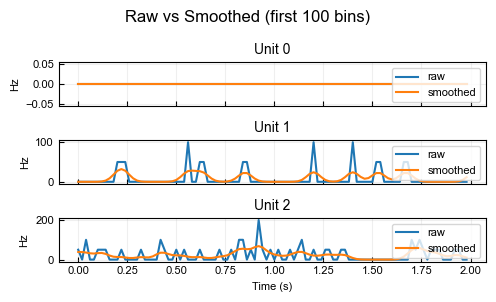

[0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1]
[7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 8 8 8 8]


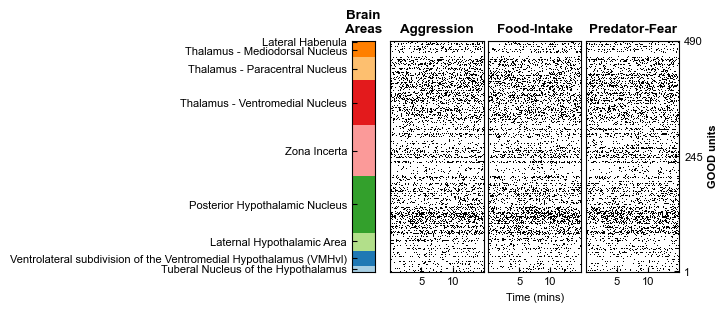

finalRThreshold=72.55 
min_weight_kept=0.02460650 
num_edges_kept=7633
Modularity: 0.5370635315180114 Clusters: 8 Components: 1
489 490


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 22 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done  41 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done  54 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done  84 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 101 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 118 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 137 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 156 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 177 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 198 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 221 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 244 tasks      | elaps

[] [978]


[Parallel(n_jobs=-1)]: Done 348 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 377 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 406 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 437 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 489 out of 489 | elapsed:    0.2s finished


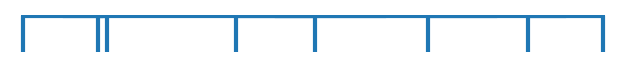

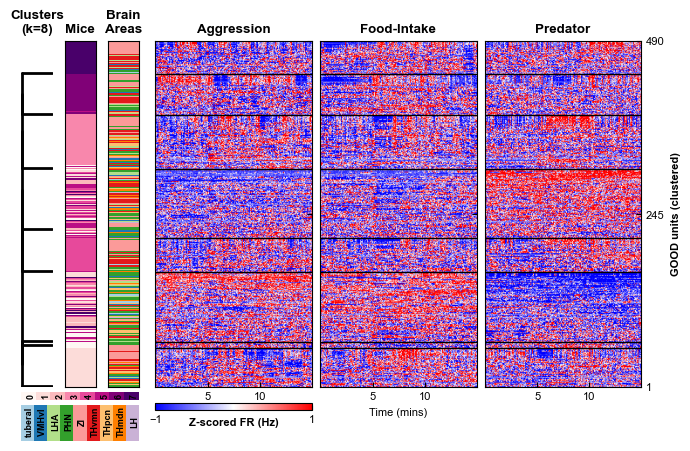

In [20]:
fsOverride = None  # if ~None, overrides sampling rate from params.py
dtFR_list = [0.02]  # firing-rate with seconds per bin
smoothperd_list = [0.25]  # smoothing parameter
smoothperdvisual_list = [5]  # another smoothing parameter for visualization
similarityMethod_list = ["Pearsonr"]
alpha = 0.001


t1 = time()
onFirst = True
for dtFR in dtFR_list:
    for smoothperd in smoothperd_list:
        for smoothperdvisual in smoothperdvisual_list:
            for similarityMethod in similarityMethod_list:
                # to extract spike data
                (
                    nGood,
                    nBins,
                    goodcluBestch,
                    goodcluBestChAreaStr,
                    goodcluBestChAreaCode,
                    goodcluToMice,
                    fr,
                ) = data_extraction_fr(
                    dtFR=dtFR,
                    phyPathList=phyPathList,
                    clusterInfoPathList=clusterInfoPathList,
                    miceNames=miceNames,
                    brainArea=brainArea,
                    areaNames=areaNames,
                    fsOverride=fsOverride,
                )
                (
                    frSmoothed,
                    frSmoothedVisual,
                ) = data_extraction_smooth_zscore(
                    fr=fr,
                    dtFR=dtFR,
                    smoothperd=smoothperd,
                    smoothperdvisual=smoothperdvisual,
                )
                (
                    nGoodAdd,
                    nBinsAdd,
                    goodcluBestchAdd,
                    goodcluBestChAreaStrAdd,
                    goodcluBestChAreaCodeAdd,
                    goodcluToMiceAdd,
                    frAddAll,
                ) = data_extraction_fr(
                    dtFR=dtFR,
                    phyPathList=phyPathListAdd,
                    clusterInfoPathList=clusterInfoPathListAdd,
                    miceNames=miceNamesAdd,
                    brainArea=brainArea,
                    areaNames=areaNames,
                    fsOverride=fsOverride,
                )
                frAdd = frAddAll[
                    :,
                    np.concatenate(
                        [
                            np.arange(int(nBinsAdd / 18), int(3 * nBinsAdd / 18)),
                            np.arange(int(4 * nBinsAdd / 18), int(5 * nBinsAdd / 18)),
                            np.arange(int(7 * nBinsAdd / 18), int(9 * nBinsAdd / 18)),
                            np.arange(int(10 * nBinsAdd / 18), int(11 * nBinsAdd / 18)),
                            np.arange(int(13 * nBinsAdd / 18), int(15 * nBinsAdd / 18)),
                            np.arange(int(16 * nBinsAdd / 18), int(17 * nBinsAdd / 18)),
                        ]
                    ),
                ]
                (
                    frSmoothedAdd,
                    frSmoothedVisualAdd,
                ) = data_extraction_smooth_zscore(
                    fr=frAdd,
                    dtFR=dtFR,
                    smoothperd=smoothperd,
                    smoothperdvisual=smoothperdvisual,
                )
                print(nBins, nBinsAdd)
                # behavior window
                (
                    aggPreAlone,
                    aggDuration,
                    aggPostAlone,
                    foodPreAlone,
                    foodDuration,
                    foodPostAlone,
                    fearPreAlone,
                    fearDuration,
                    fearPostAlone,
                    winA,
                    winF,
                    winP,
                    winPre,
                    winDur,
                    winPost,
                    winAll,
                ) = getwin(nBins)
                nBinsL = nBins // int(round(smoothperdvisual / dtFR))
                (
                    aggPreAloneL,
                    aggDurationL,
                    aggPostAloneL,
                    foodPreAloneL,
                    foodDurationL,
                    foodPostAloneL,
                    fearPreAloneL,
                    fearDurationL,
                    fearPostAloneL,
                    winAL,
                    winFL,
                    winPL,
                    winPreL,
                    winDurL,
                    winPostL,
                    winAllL,
                ) = getwin(nBinsL)
                goodcluBestch = np.concatenate(
                    [goodcluBestch, goodcluBestchAdd], axis=0
                )
                goodcluBestChAreaStr = np.concatenate(
                    [goodcluBestChAreaStr, goodcluBestChAreaStrAdd], axis=0
                )
                goodcluBestChAreaCode = np.concatenate(
                    [goodcluBestChAreaCode, goodcluBestChAreaCodeAdd], axis=0
                )
                goodcluToMice = np.concatenate(
                    [goodcluToMice, goodcluToMiceAdd], axis=0
                )

                frZ = zscoring(fr, baseline=np.arange(nBins))[0]
                frSmoothedZ = zscoring(frSmoothed, baseline=np.arange(nBins))[0]
                frSmoothedVisualZ = zscoring(
                    frSmoothedVisual, baseline=np.arange(nBinsL)
                )[0]
                frZAdd = zscoring(frAdd, baseline=np.arange(nBins))[0]
                frSmoothedZAdd = zscoring(frSmoothedAdd, baseline=np.arange(nBins))[0]
                frSmoothedVisualZAdd = zscoring(
                    frSmoothedVisualAdd,
                    baseline=np.arange(nBinsL),
                )[0]
                print(
                    "\n",
                    fr.shape,
                    frSmoothed.shape,
                    frSmoothedVisual.shape,
                    frZ.shape,
                    frSmoothedZ.shape,
                    frSmoothedVisualZ.shape,
                )
                print(
                    frAdd.shape,
                    frSmoothedAdd.shape,
                    frSmoothedVisualAdd.shape,
                    frZAdd.shape,
                    frSmoothedZAdd.shape,
                    frSmoothedVisualZAdd.shape,
                )

                # test smoothing and binary FR
                if onFirst:
                    smoothing_plot(fr=fr, frSmoothed=frSmoothed, dtFR=dtFR)
                    binary_fr(
                        fr=fr,
                        frAdd=frAdd,
                        goodcluBestChAreaCode=goodcluBestChAreaCode,
                        nAreas=nAreas,
                        areaNamesFull=areaNamesFull,
                    )
                    onFirst = False

                t2 = time()
                # graph clustering ==== optimized ====
                data = np.concatenate([frSmoothedZ, frSmoothedZAdd])
                dataVisual = np.concatenate([frSmoothedVisualZ, frSmoothedVisualZAdd])
                (Z, elbowIdx, kBest, leafOrder, cluInLeafOrder, Q) = (
                    graph_clustering_refinement(
                        data=data,
                        similarityMethod=similarityMethod,
                        dtFR=dtFR,
                        isbenchmarking=False,
                        alpha=alpha,
                        simpleplot=True,
                    )
                )
                graph_clustering_plot_wider_refinement(
                    dataVisual=dataVisual,
                    goodcluToMice=goodcluToMice,
                    nMice=nMice,
                    miceNames=miceNames,
                    miceNamesAdd=miceNamesAdd,
                    goodcluBestChAreaCode=goodcluBestChAreaCode,
                    nAreas=nAreas,
                    areaNames=areaNames,
                    Z=Z,
                    elbowIdx=elbowIdx,
                    kBest=kBest,
                    leafOrder=leafOrder,
                    cluInLeafOrder=cluInLeafOrder,
                    dtFR=dtFR,
                    smoothperd=smoothperd,
                    smoothperdvisual=smoothperdvisual,
                    similarityMethod=similarityMethod,
                    alpha=alpha,
                )